# CSE 25 – Introduction to Artificial Intelligence  
## Worksheet 16: Word Embeddings and Semantic Spaces

> How can we represent the meanings of words so that computers can measure similarity and relationships?

### Guiding Questions
1. How do computers decide if two words are related?
2. What is a semantic space, and how can we visualize word meanings?
3. How do word embeddings capture similarity and analogies?
4. What are some ways to measure similarity between word vectors?
5. How can bias appear in word embeddings, and why does it matter?

### Learning Objectives
By the end of this worksheet, you will be able to:
- Explain the concept of a semantic space for words
- Visualize and interpret simple word embeddings
- Measure similarity between words using distance and dot product
- Understand how analogies can be solved with vector arithmetic
- Identify and discuss bias in word embeddings and its implications

**Instructions:**

Create a copy of this notebook and complete it during class.  
Work through the cells below **in order**.

You may discuss with your neighbors, but make sure you understand  
what each step is doing and why.

**Submission**

When finished, download the notebook as a PDF and upload it to Gradescope under  
`In-Class – Week 10 Tuesday`.

To download as a PDF on DataHub:  
`File -> Save and Export Notebook As -> PDF`

#### Acticity: Play Semantris

We will start by playing a game called [Semantris](https://research.google.com/semantris/)

Your task is to play the game and observe **how the AI decides which words are related**.

We will try two different versions of the game:
1. **Arcade Mode**
2. **Blocks Mode**

##### Part 1 - Arcade Mode

1. Open **Arcade Mode**.
2. Play one or two games.
3. Type a word that you think is **related to the clue**.

For each clue, try different kinds of words:

- A **synonym** (same meaning)
- A word with a **similar root or prefix**
- An **antonym** (opposite meaning)
- A word that is **completely unrelated**

Observe how the system responds to each type of word.

Q. Write down what you observed while playing.

- What kinds of words tended to work best?
- Did the system ever accept a word that was **not an exact synonym**?
- Did the system ever reject a word that **you thought should have worked**?
- What happened when you entered **completely unrelated words**?

Write your observations below:

`YOUR OBSERVATIONS HERE`

##### Part 2 - Blocks Mode

Now switch to **Blocks Mode** in Semantris.

Play a few rounds of the game. This mode moves more slowly and gives you more time to observe how the system behaves.

While playing, try the following:

- Enter words that you think are **similar to multiple blocks** on the screen.
- Try words that might be **related to more than one clue** at the same time.
- Observe which block the system removes.

Pay attention to whether the system chooses the word **you expected**, or a **different one**.


Q Write down what you observed while playing.

- When you entered a word related to **multiple blocks**, which block did the system remove?
- Did the system ever remove a **different block than the one you expected**?
- Were there cases where a word seemed related to several clues?
- What patterns do you notice about how the system decides which block to remove?

Write some of your observations below:

`YOUR OBSERVATIONS HERE`

##### Discuss and reflect:

Based on your experience with both versions of the game:

Q. How do you think the AI system decides which words are related? What information might it be using to make these decisions?

Write your hypothesis.

`YOUR HYPOTHESIS HERE`

#### What might the AI be doing?

In Semantris, the system seemed to know which words were related.

But how could a computer measure the **similarity between words**?

One idea is to represent words as **points in a space**, where similar words are closer together.

In the next activity we will explore a **simplified semantic space** where each word is represented by coordinates.

#### Building a Semantic Space

Consider the words:

**man, woman, boy, girl**

What features might distinguish these words?

Discuss with your group and write two possible dimensions.

- Dimension 1: `YOUR ANSWER HERE`
- Dimension 2: `YOUR ASNWER HERE`

<!-- 
Two useful semantic features are:

- **Gender**  
- **Age**

These features capture part of the meaning of each word.

If we associate a numerical scale with each feature, we can assign coordinates to each word. Gender and age are examples of *semantic features*. -->



| Word  | (x) |(y) | Coordinates |
|-------|------------|---------|-------------|
| man   | 1          | 7       | [1, 7]      |
| woman | 9          | 7       | [9, 7]      |
| boy   | 1          | 2       | [1, 2]      |
| girl  | 9          | 2       | [9, 2]      |

We can plot these on a graph where the x-axis represents **gender** and the y-axis represents **age**.

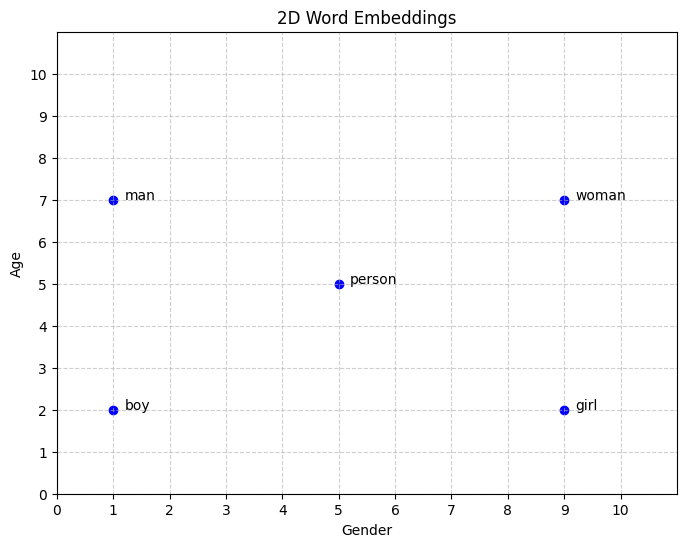

In [26]:
import matplotlib.pyplot as plt
import math

words_2d = {
    "man": [1, 7],
    "woman": [9, 7],
    "boy": [1, 2],
    "girl": [9, 2],
    "person": [5, 5]
}

def plot_space(data, title):
    plt.figure(figsize=(8, 6))
    for word, coords in data.items():
        plt.scatter(coords[0], coords[1], color='blue')
        plt.text(coords[0] + 0.2, coords[1], word, fontsize=10)
    
    plt.xlim(0, 11); plt.ylim(0, 11)
    plt.xlabel("Gender")
    plt.ylabel("Age")
    plt.xticks(range(0, 11, 1))
    plt.yticks(range(0, 11, 1))
    plt.title(title)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_space(words_2d, "2D Word Embeddings")

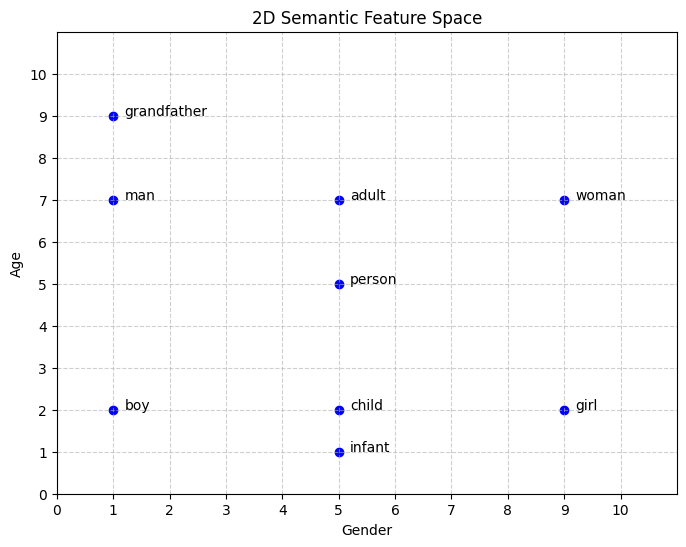

In [27]:
# Let's add more words to the space, and see how they relate to the original four words.
# Table of Word Coordinates from the tutorial
additional_words = {
    "grandfather": [1, 9], 
    "adult": [5, 7], 
    "child": [5, 2], 
    "infant": [5, 1]
}

# Add the additional words to the original dictionary
words_2d.update(additional_words)

# Plot the updated space with the new words
plot_space(words_2d, "2D Semantic Feature Space")

Q. How would you represent the words "grandmother", "grandparent", "teenager", and "octogenarian"?

*Hint: We can extrapolate the gender and age coordinates based on the values for the words we've already defined.*

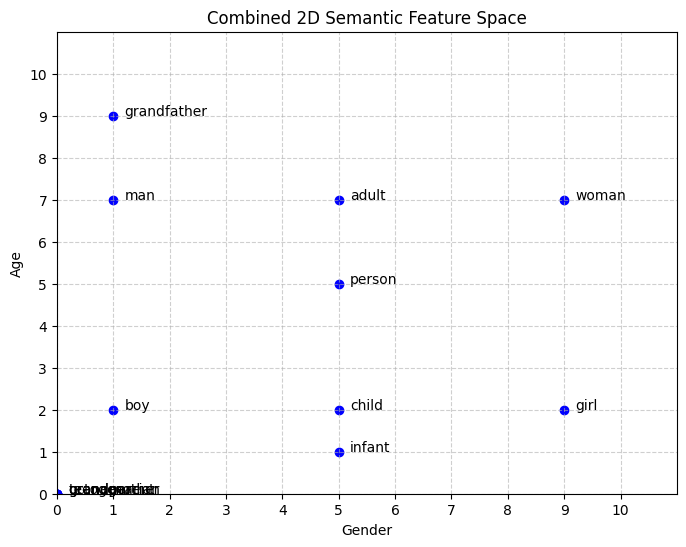

In [28]:
# Change these coordinates to reflect the semantic features of the new words
# YOUR CODE HERE 
additional_words = {
    "grandmother": [0, 0],
    "grandparent": [0, 0],
    "teenager": [0, 0],
    "octogenarian": [0, 0]
}

# Combine with original words for plotting
combined_words = {**words_2d, **additional_words}

plot_space(combined_words, "Combined 2D Semantic Feature Space")

Now that each word has coordinates in this space, we can measure how **similar two words are** by measuring the **distance between their points**.

### Measuring Distance Between Words

So far we have represented words as **points in a semantic space**. Another way to think about these points is as **vectors**.

A **vector** is an arrow that starts at the origin and ends at a point.

For example, if the word **child** has coordinates [5, 2] we can draw it as an arrow from the origin **[0, 0]** to the point **[5, 2]**.

In this way, every word becomes a vector pointing to its position in the semantic space.

Below we visualize all the words in our 2D semantic space as vectors.

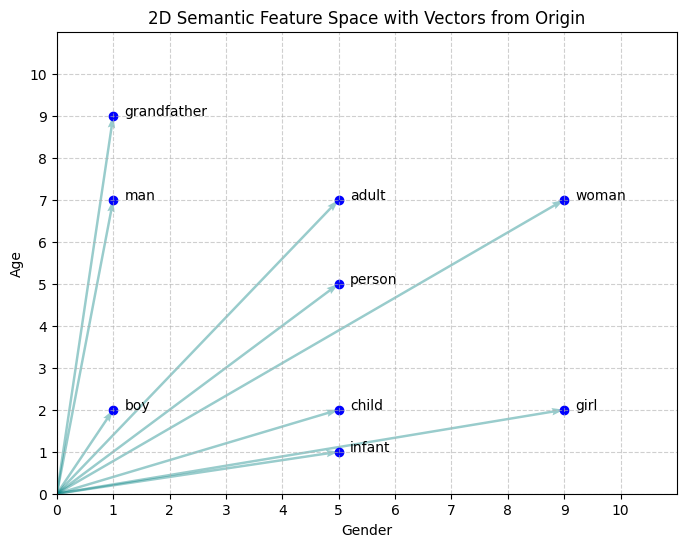

In [29]:
# Plot words as points and vectors from origin (0,0)
def plot_words_from_origin(words):
    plt.figure(figsize=(8, 6))

    for word, (x, y) in words.items():
        # Vector arrow from origin to the word point
        plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
                color='teal', alpha=0.4, width=0.004)
        # Point + label
        plt.scatter(x, y, color='blue')
        plt.text(x + 0.2, y, word, fontsize=10)

    plt.xlim(0, 11)
    plt.ylim(0, 11)
    plt.xlabel("Gender")
    plt.ylabel("Age")
    plt.xticks(range(0, 11, 1))
    plt.yticks(range(0, 11, 1))
    plt.title("2D Semantic Feature Space with Vectors from Origin")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_words_from_origin(words_2d)


Q. If two words have **similar meanings**, where should they appear in this space - close together or far apart? Why?

#### Measuring Euclidean Distance

We can compare two words by measuring the **distance between their points** in the semantic space.

For example:

- **boy** has coordinates `[1, 2]`
- **infant** has coordinates `[5, 1]`

To compute the vector from **boy → infant**, subtract the coordinates:

[5, 1] − [1, 2] = [4, -1]

The length of a vector `[x, y]` is the Euclidean distance between the points:

$$
\sqrt{x^2 + y^2}
$$

So the distance between **boy** and **infant** is:

$$
\sqrt{4^2 + (-1)^2} = \sqrt{17} \approx 4.12

Here are the distances from **boy** to several other words:

| Word | Distance from "boy" |
|-----|---------------------|
| child | 4.00 |
| infant | 4.12 |
| man | 5.00 |
| adult | 6.40 |
| grandfather | 7.00 |
| girl | 8.00 |
| woman | 9.43 |

1. Which word is **most similar to "boy"** according to this distance measure?

2. Which word is **least similar**?

3. Does this match your intuition about the meanings of these words?

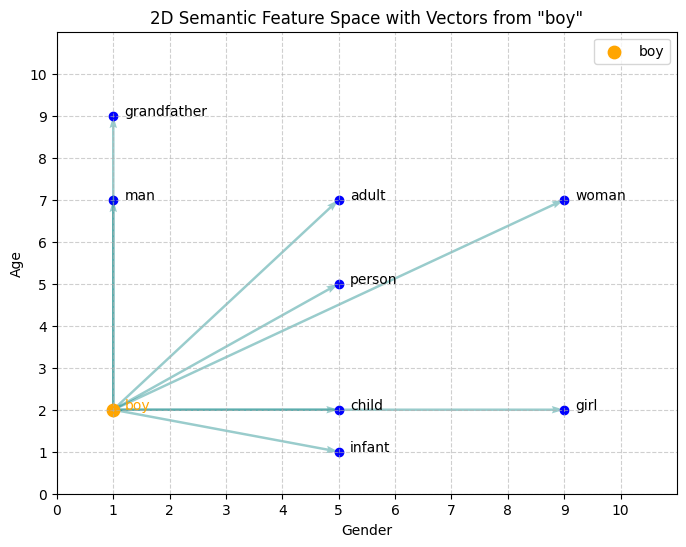

In [12]:
# Plot words as points and vectors from "boy"
plt.figure(figsize=(8, 6))

boy_coords = words_2d["boy"]

for word, (x, y) in words_2d.items():
    if word == "boy":
        continue
    # Vector arrow from "boy" to the word point
    plt.quiver(boy_coords[0], boy_coords[1], x - boy_coords[0], y - boy_coords[1],
               angles='xy', scale_units='xy', scale=1,
               color='teal', alpha=0.4, width=0.004)
    # Point + label
    plt.scatter(x, y, color='blue')
    plt.text(x + 0.2, y, word, fontsize=10)

# Draw "boy" in a different color
plt.scatter(boy_coords[0], boy_coords[1], color='orange', s=80, label='boy')
plt.text(boy_coords[0] + 0.2, boy_coords[1], "boy", fontsize=10, color='orange')

plt.xlim(0, 11)
plt.ylim(0, 11)
plt.xlabel("Gender")
plt.ylabel("Age")
plt.xticks(range(0, 11, 1))
plt.yticks(range(0, 11, 1))
plt.title('2D Semantic Feature Space with Vectors from "boy"')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

#### Measuring Similarity With the Dot Product

You can see that the closest word to **"boy"** is **"child"**, and **"infant"** is only slightly further away.

Euclidean distance is a reasonable way to measure similarity between words.

However, in **real word embeddings**, vectors often differ in **length** as well as direction. Because of this, Euclidean distance is not always the best measure of similarity.

Instead, we often compare vectors using the **dot product**, which measures how well two vectors point in the **same direction**.

If we have two vectors

$$
[x_1, y_1] \quad \text{and} \quad [x_2, y_2]
$$

their dot product is

$$
x_1 x_2 + y_1 y_2
$$

Geometrically, the dot product depends on the **angle between the two vectors**.

- If two vectors point in **similar directions**, the angle between them is small and the dot product is **large**.
- If they point in **very different directions**, the angle is larger and the dot product is **smaller**.

Because of this, the dot product acts as a **similarity measure** rather than a distance measure.

##### A Problem With Our Current Space

There is one issue with using the dot product in our current semantic space.

All of our word vectors start at the **origin (0,0)**, and all of the words lie in the **upper-right part of the space**.

Because of this, many vectors end up pointing in roughly the **same direction**, even if the words are not actually very similar.

For example, consider the vectors for:

- **boy** → [1, 2]  
- **child** → [5, 2]  
- **adult** → [5, 7]

Even though **boy** is clearly closer in meaning to **child**, the vectors for **boy** and **adult** point in a more similar direction from the origin.

This means the **angle between "boy" and "adult" can actually be smaller** than the angle between **"boy" and "child"**, which would incorrectly suggest that **boy is more similar to adult**.

To fix this problem, we shift the entire space so that the **center of all the points becomes the origin**.

**Recentering the Space**

We compute the **mean (average)** of all the coordinates and subtract it from every point.

In [13]:
# Create a new words_2d dictionary with zero-mean coordinates

# Compute the mean for each dimension
mean_x = sum(v[0] for v in words_2d.values()) / len(words_2d)
mean_y = sum(v[1] for v in words_2d.values()) / len(words_2d)

# Subtract the mean from each coordinate
words_2d_zero_mean = {
    word: [x - mean_x, y - mean_y]
    for word, (x, y) in words_2d.items()
}

# Show the new zero-mean coordinates, rounded to 2 decimal places
for word, coords in words_2d_zero_mean.items():
    print(f"{word}: [{coords[0]:.2f}, {coords[1]:.2f}]")

man: [-3.56, 2.33]
woman: [4.44, 2.33]
boy: [-3.56, -2.67]
girl: [4.44, -2.67]
person: [0.44, 0.33]
grandfather: [-3.56, 4.33]
adult: [0.44, 2.33]
child: [0.44, -2.67]
infant: [0.44, -3.67]


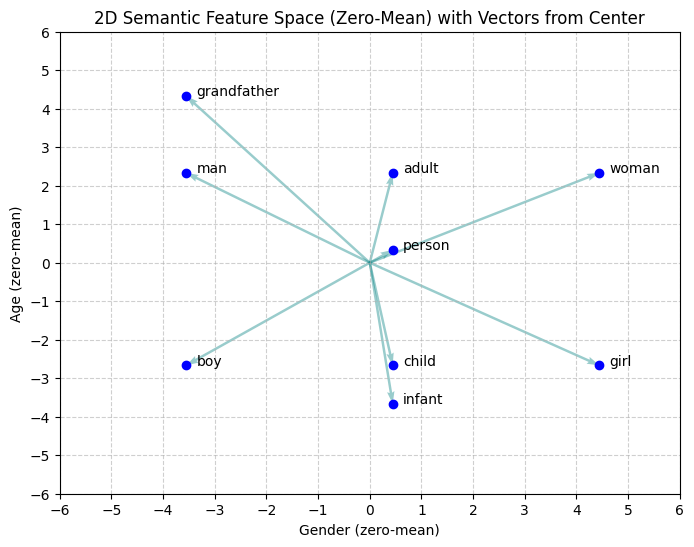

In [14]:
# Plot words as points and vectors from the new origin (centered/zero-mean)
plt.figure(figsize=(8, 6))

for word, (x, y) in words_2d_zero_mean.items():
    # Vector arrow from origin (0,0) to the zero-mean word point
    plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
               color='teal', alpha=0.4, width=0.004)
    # Point + label
    plt.scatter(x, y, color='blue')
    plt.text(x + 0.2, y, word, fontsize=10)

plt.xlim(-6, 6)
plt.ylim(-6, 6)
plt.xlabel("Gender (zero-mean)")
plt.ylabel("Age (zero-mean)")
plt.xticks(range(-6, 7, 1))
plt.yticks(range(-6, 7, 1))
plt.title("2D Semantic Feature Space (Zero-Mean) with Vectors from Center")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### One More Adjustment: Normalizing the Vectors

After shifting the space so that the center is at the origin, the angles between vectors behave more sensibly. For example, the angle between **boy** and **child** is now smaller than the angle between **boy** and **adult**, which better reflects their meanings.

However, there is still one issue.

The dot product between two vectors does not depend only on the **angle between them**. It also depends on the **lengths of the vectors**.

Mathematically, the dot product can be written in two equivalent ways:

$$
u \cdot v = x_1x_2 + y_1y_2 = \|u\|\,\|v\|\cos(\theta)
$$

The first expression,

$$
x_1x_2 + y_1y_2
$$

comes directly from multiplying the coordinates of the vectors.

The second expression,

$$
\|u\|\|v\|\cos(\theta)
$$

comes from geometry. Here:

- $ \|u\| $ and $ \|v\| $ are the **lengths of the vectors**
- $ \theta $ is the **angle between them**
- $ \cos(\theta) $ measures how aligned the vectors are

These two formulas are mathematically **equivalent ways of computing the same quantity**. One uses coordinates, while the other describes the same result using geometry.

Because the dot product depends on vector **lengths**, two vectors that point in the same direction but have different lengths can produce different values.

To make similarity depend **only on direction**, we normalize each vector so that its length becomes **1**.

Given a vector

$$
u = [x, y]
$$

with length

$$
\|u\| = \sqrt{x^2 + y^2}
$$

we create a **unit vector**

$$
u/\|u\| = [x/\|u\|,\; y/\|u\|]
$$

After normalization, all vectors lie on a **circle of radius 1**, and the dot product becomes exactly the **cosine similarity** between the vectors.

In [15]:
# Convert zero-mean points to unit vectors (all points lie on a circle of radius 1)
unit_vectors = {}
for word, (x, y) in words_2d_zero_mean.items():
    mag = math.sqrt(x**2 + y**2)
    if mag == 0:
        unit_vectors[word] = [0, 0]
    else:
        unit_vectors[word] = [x / mag, y / mag]

# Show the unit vectors, rounded to 2 decimal places
for word, coords in unit_vectors.items():
    print(f"{word}: [{coords[0]:.2f}, {coords[1]:.2f}]")

man: [-0.84, 0.55]
woman: [0.89, 0.46]
boy: [-0.80, -0.60]
girl: [0.86, -0.51]
person: [0.80, 0.60]
grandfather: [-0.63, 0.77]
adult: [0.19, 0.98]
child: [0.16, -0.99]
infant: [0.12, -0.99]


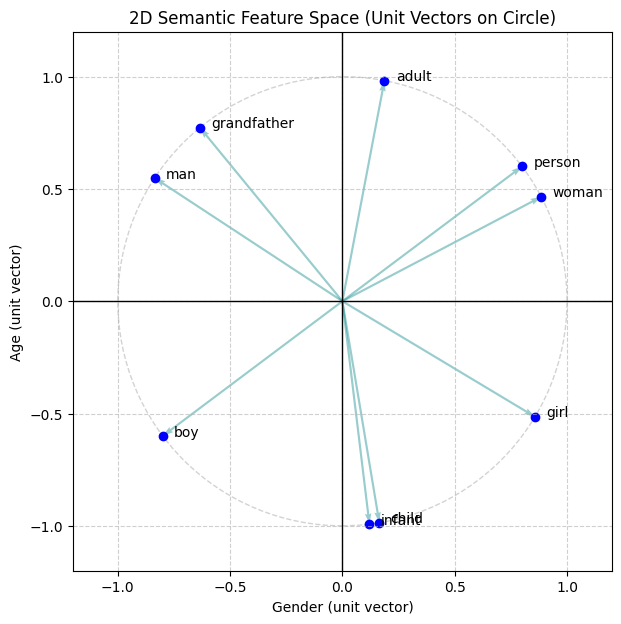

In [16]:
# Plot unit vectors (zero-mean, length 1) for all words
plt.figure(figsize=(7, 7))

# Draw a circle of radius 1 for reference
circle = plt.Circle((0, 0), 1, color='lightgray', fill=False, linestyle='--')
plt.gca().add_patch(circle)

for word, (x, y) in unit_vectors.items():
    # Vector arrow from origin to the unit vector point
    plt.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1,
               color='teal', alpha=0.4, width=0.004)
    # Point + label
    plt.scatter(x, y, color='blue')
    plt.text(x + 0.05, y, word, fontsize=10)

plt.xlim(-1.2, 1.2)
plt.ylim(-1.2, 1.2)
plt.xlabel("Gender (unit vector)")
plt.ylabel("Age (unit vector)")
plt.title("2D Semantic Feature Space (Unit Vectors on Circle)")
plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().set_aspect('equal')
plt.show()

### Adding Complexity: Royalty

Now let's consider the words **king**, **queen**, **prince**, and **princess**.

They share the same **gender** and **age** attributes as **man**, **woman**, **boy**, and **girl**, but they do **not** mean the same thing.

To distinguish them, we need a new semantic feature: **royalty**.

This means we now move from a **2D semantic space** to a **3D semantic space**.

| Word      | Gender (x) | Age (y) | Royalty (z) | Coordinates     |
|-----------|------------|---------|-------------|----------------|
| man       | 1          | 7       | 1           | [1, 7, 1]      |
| woman     | 9          | 7       | 1           | [9, 7, 1]      |
| boy       | 1          | 2       | 1           | [1, 2, 1]      |
| girl      | 9          | 2       | 1           | [9, 2, 1]      |
| king      | 1          | 8       | 8           | [1, 8, 8]      |
| queen     | 9          | 7       | 8           | [9, 7, 8]      |
| prince    | 1          | 2       | 8           | [1, 2, 8]      |
| princess  | 9          | 2       | 8           | [9, 2, 8]      |

In [17]:
words_3d = {
    "man": [1, 7, 1],
    "woman": [9, 7, 1],
    "boy": [1, 2, 1],
    "girl": [9, 2, 1],
    "king": [1, 8, 8],
    "queen": [9, 7, 8],
    "prince": [1, 2, 8],
    "princess": [9, 2, 8]
}

In [ ]:
import plotly.graph_objects as go
import numpy as np

def plot_words_3d(words_3d, 
                  arrows=None, 
                  highlight_points=None, 
                  colorscale="Viridis", 
                  title="3D Semantic Feature Space"):
    """
    words_3d: dict of word -> [x, y, z]
    arrows: list of dicts with keys 'start', 'end', 'color', 'name', 'dash'
    highlight_points: list of dicts with keys 'word', 'color', 'size', 'symbol', 'name', 'showlegend'
    """
    labels = list(words_3d.keys())
    xs = [coords[0] for coords in words_3d.values()]
    ys = [coords[1] for coords in words_3d.values()]
    zs = [coords[2] for coords in words_3d.values()]

    fig = go.Figure()

    # Scatter points (all words)
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode="markers+text",
        text=labels,
        textposition="top center",
        marker=dict(size=6, color=zs, colorscale=colorscale, opacity=0.85),
        showlegend=False
    ))

    # Draw arrows if provided
    if arrows:
        for arrow in arrows:
            start = np.array(words_3d[arrow['start']])
            end = np.array(words_3d[arrow['end']])
            fig.add_trace(go.Scatter3d(
                x=[start[0], end[0]], y=[start[1], end[1]], z=[start[2], end[2]],
                mode="lines",
                line=dict(
                    color=arrow.get('color', 'black'), 
                    width=arrow.get('width', 4), 
                    dash=arrow.get('dash', None)
                ),
                name=arrow.get('name', f"{arrow['start']}→{arrow['end']}")
            ))

    # Highlight points if provided
    if highlight_points:
        for pt in highlight_points:
            coords = pt['coords'] if 'coords' in pt else words_3d[pt['word']]
            fig.add_trace(go.Scatter3d(
                x=[coords[0]], y=[coords[1]], z=[coords[2]],
                mode="markers+text",
                marker=dict(
                    size=pt.get('size', 8), 
                    color=pt.get('color', 'gold'), 
                    symbol=pt.get('symbol', 'x')
                ),
                text=[pt.get('label', pt.get('word', ''))], 
                textposition="top center",
                name=pt.get('name', pt.get('word', '')),
                showlegend=pt.get('showlegend', False)
            ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="Gender (x)",
            yaxis_title="Age (y)",
            zaxis_title="Royalty (z)",
            xaxis=dict(range=[0, 10]),
            yaxis=dict(range=[0, 10]),
            zaxis=dict(range=[0, 10]),
        ),
        width=900,
        height=700,
        legend=dict(itemsizing='constant')
    )
    fig.show()

# --- Usage Example 1: Just the points ---
plot_words_3d(words_3d, colorscale="Rainbow", title="Interactive 3D Semantic Feature Space")

#### Analogies by Vector Arithmetic (OPTIONAL)

Analogies express relationships between concepts.

For example:

**man is to king as woman is to ____**

We can solve this numerically:

1. Find the relationship between **man** and **king** by computing:

$$
king - man
$$

2. Add that relationship to **woman**.

3. Find the word closest to the resulting vector.

In [24]:
def vector_sub(v1, v2):
    return [a - b for a, b in zip(v1, v2)]

def vector_add(v1, v2):
    return [a + b for a, b in zip(v1, v2)]

rel = vector_sub(words_3d["king"], words_3d["man"])
result = vector_add(rel, words_3d["woman"])

print("Relationship vector (king - man):", rel)
print("Resulting vector (woman + relationship):", result)
print("Actual queen vector:", words_3d["queen"])

Relationship vector (king - man): [0, 1, 7]
Resulting vector (woman + relationship): [9, 8, 8]
Actual queen vector: [9, 7, 8]


In [25]:
# Finding the closest word to the resulting vector
closest_word = None
closest_dist = float("inf")

# We can use Euclidean distance to find the closest word in the space to the resulting vector
for w, vec in words_3d.items():
    if w == "woman":
        continue
    # Compute Euclidean distance manually
    d = sum((a - b) ** 2 for a, b in zip(vec, result)) ** 0.5
    if d < closest_dist:
        closest_dist = d
        closest_word = w

# Prepare for plotting
arrows = [
    {'start': 'man', 'end': 'king', 'color': 'blue', 'name': 'vector difference (man→king)'},
    {'start': 'woman', 'end': 'target', 'color': 'green', 'name': 'apply difference (woman→target)', 'dash': 'dash'}
]
words_3d_with_target = dict(words_3d)
words_3d_with_target['target'] = result

highlight_points = [
    {'coords': result, 'color': 'gold', 'size': 5, 'symbol': 'x', 'label': 'target', 'name': 'analogy target', 'showlegend': False},
    {'word': closest_word, 'color': 'crimson', 'size': 5, 'label': closest_word, 'name': f'closest: {closest_word}', 'showlegend': True}
]

plot_words_3d(
    words_3d_with_target,
    arrows=arrows,
    highlight_points=highlight_points,
    colorscale="Viridis",
    title="Analogy: man : king :: woman : ?"
)

#### Word Embeddings

Going from two semantic features to three allowed us to represent more words.

But are three features enough to represent words such as **cucumber**, **smiled**, or **honesty**? Probably not! 

To represent the complexity of a large vocabulary, we would need **many more semantic features**.

Instead of designing these features by hand, we can let a machine learning algorithm learn them automatically from large amounts of text. These learned vector representations are called **word embeddings**.

A typical word embedding might use a space with **hundreds of dimensions**, so each word is represented by hundreds of numbers.

These learned representations support:

- similarity
- analogies
- search
- recommendation
- modern language models

##### How Are Word Embeddings Learned?

In early models such as *word2vec*, embeddings are learned using a simple neural network.

Each word in the vocabulary is first represented as a **one-hot vector**.  A one-hot vector has a 1 in the position of the word and 0 everywhere else.

For example, if the vocabulary is:

[cat, dog, apple, car]

then the word **dog** might be represented as:

[0, 1, 0, 0]

A neural network then learns to **encode this one-hot vector into a dense vector**.  
This dense vector is the **word embedding**.

<img src="images/word-embedding.png" width="800">
image source: https://artint.info/3e/html/ArtInt3e.Ch8.S5.html

The model learns these embeddings by predicting words that appear near each other in text.

Two common training methods are:

- *CBOW (Continuous Bag of Words)*: The model predicts a word from its surrounding context words.
- *Skip-gram*: The model predicts surrounding words from a single word.

By training on large text corpora, the model learns embeddings where *similar words end up close together in the vector space*.

#### Activity: Investigating Bias in Word Embeddings

Word embeddings are learned from large text corpora written by humans.
As a result, they can also reflect **patterns and biases present in the data**.

In this activity, we will explore how bias can appear in embedding spaces.

Open the interactive tool: https://lamyiowce.github.io/word2viz/

Using the **gender analogy explorer**, search for the following words and observe the nearest neighbors:

- doctor  
- nurse  
- engineer  
- teacher  
- homemaker  
- programmer  

**Questions**

1. What kinds of words appear near each profession?
2. Do you notice any patterns related to **gender**?
3. Are any of the results surprising?

Try exploring other words and analogies.

4. Can you find any other types of bias in the data?

#### Further Reading

If you are curious to learn more about the ideas behind the systems we explored in this lecture:

- Mikolov et al., *Efficient Estimation of Word Representations in Vector Space*  - [Paper Link](https://arxiv.org/abs/1301.3781)   

- Cer et al., *Universal Sentence Encoder* - [Paper Link](https://arxiv.org/abs/1803.11175) 
*(Semantris is based on this work)*

- [GloVe]( https://nlp.stanford.edu/projects/glove/) (Global Vectors for Word Representation) – Stanford NLP  


#### Interactive Tools
- [Word Embedding Demo](https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/index.html)

- [Word2Viz](https://lamyiowce.github.io/word2viz/) : Interactive Embedding Explorer based on [GloVe]( https://nlp.stanford.edu/projects/glove/)
  

#### Acknowledgment

Parts of this lecture are based on [Word Embedding Demo](https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/index.html) developed at Carnegie Mellon University by Touretzky, D.